**Author:** Biswajit Jana  
**Date:** February 10, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-hr-diagram-pleiades/notebook.ipynb)

# A real Hertzsprung-Russell diagram for the Pleiades

**Learning goals** — after this notebook you'll be able to:
- Write and run a real ADQL query against the Gaia DR3 archive (`gaiadr3.gaia_source`) with `astroquery`.
- Apply standard astrometric/photometric quality cuts (parallax signal-to-noise, RUWE, flux-error flags) and quantify how many stars they remove.
- Convert an apparent magnitude and a parallax into an absolute magnitude (`M_G`), the quantity that actually reveals a star's true brightness.
- Build a Hertzsprung-Russell (color-magnitude) diagram and overlay an empirical main-sequence ridge line.
- Compare the Pleiades' main-sequence turnoff to another cluster and connect turnoff position to cluster age.

**Background.** A parallax is the tiny apparent shift in a star's position over the year as Earth orbits the Sun; its size in milliarcseconds directly gives distance in parsecs (`d = 1000/parallax_mas`). An HR diagram plots stars' colors (a stand-in for surface temperature) against their absolute magnitudes (a stand-in for true luminosity, i.e. brightness corrected for distance). Most stars sit on a narrow diagonal band called the **main sequence**, where they spend most of their lives burning hydrogen; the point where a cluster's main sequence bends away from that band toward the upper right is the **turnoff**, and its position tells you the cluster's age — the more massive (bluer, brighter) stars have already evolved off the main sequence in older clusters, so an older cluster's turnoff sits lower and redder. The Pleiades ("Seven Sisters") is a nearby young open cluster about 136 pc away, still fully on the main sequence, which makes it an excellent benchmark case.

## 1. Query real Gaia DR3 data for the Pleiades field

In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

# Pleiades cluster center (RA/Dec) and a search cone wide enough to catch
# real members but small enough to keep the query fast. I pre-filter on a
# wide parallax window in the ADQL itself (centered on the cluster's known
# ~136 pc distance) since that lets the archive use its parallax index and
# keeps the query from timing out over such a dense field.
ra_c, dec_c, radius_deg = 56.75, 24.12, 1.0

query_raw = f"""
SELECT TOP 5000 source_id, ra, dec, parallax, parallax_error, pmra, pmdec,
       phot_g_mean_mag, bp_rp, ruwe, phot_bp_mean_flux_over_error,
       phot_rp_mean_flux_over_error
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec),
                  CIRCLE('ICRS', {ra_c}, {dec_c}, {radius_deg}))
  AND parallax BETWEEN 3 AND 12
  AND phot_g_mean_mag < 18
"""
job_raw = Gaia.launch_job(query_raw)
tab_raw = job_raw.get_results()
n_raw = len(tab_raw)
print(f"Raw query returned {n_raw} sources within {radius_deg} deg of the Pleiades center.")

Raw query returned 855 sources within 1.0 deg of the Pleiades center.


## 2. Quality cuts and cluster membership

Real Gaia catalogs contain plenty of noise: stars with poorly-measured parallax, bad astrometric fits, or noisy photometry. I apply, in order:

1. **Parallax S/N > 5** (`parallax / parallax_error > 5`) — keeps only stars whose distance is measured to better than 20%.
2. **RUWE < 1.4** — the *renormalized unit weight error* flags sources where the single-star astrometric model fit poorly (often unresolved binaries or blends).
3. **Photometric quality** — BP and RP flux S/N > 10, so the color (`bp_rp`) isn't dominated by noise.
4. **Cluster parallax window** — Pleiades is at ~136 pc (~7.35 mas parallax); I keep stars with parallax in [6.5, 8.2] mas as a first-pass kinematic membership cut.

I print the surviving count after each cut so the effect of each one is visible.

In [2]:
parallax = np.array(tab_raw['parallax'])
parallax_err = np.array(tab_raw['parallax_error'])
ruwe = np.array(tab_raw['ruwe'])
bp_sn = np.array(tab_raw['phot_bp_mean_flux_over_error'])
rp_sn = np.array(tab_raw['phot_rp_mean_flux_over_error'])

mask = np.ones(len(tab_raw), dtype=bool)
print(f"Start: {mask.sum()} sources")

mask &= (parallax / parallax_err) > 5
print(f"After parallax S/N > 5: {mask.sum()} sources")

mask &= np.nan_to_num(ruwe, nan=99) < 1.4
print(f"After RUWE < 1.4: {mask.sum()} sources")

mask &= np.nan_to_num(bp_sn, nan=0) > 10
mask &= np.nan_to_num(rp_sn, nan=0) > 10
print(f"After BP/RP flux S/N > 10: {mask.sum()} sources")

mask &= (parallax > 6.5) & (parallax < 8.2)
print(f"After Pleiades parallax window (6.5-8.2 mas): {mask.sum()} sources")

tab = tab_raw[mask]
n_members = len(tab)
print(f"\nFinal Pleiades candidate member sample: {n_members} stars (from {n_raw} raw sources).")

Start: 855 sources
After parallax S/N > 5: 855 sources
After RUWE < 1.4: 723 sources
After BP/RP flux S/N > 10: 703 sources
After Pleiades parallax window (6.5-8.2 mas): 400 sources

Final Pleiades candidate member sample: 400 stars (from 855 raw sources).


## 3. Absolute magnitude and the HR diagram

Members with positive parallax used for the HR diagram: 400
Median distance: 135.9 pc
Distance range (16th-84th pct): 133.2-138.8 pc


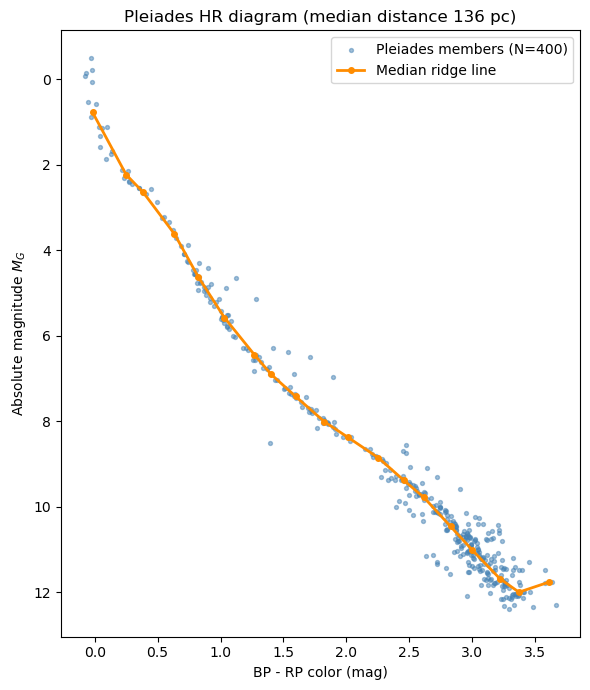

In [3]:
parallax_m = np.array(tab['parallax'])
g_mag = np.array(tab['phot_g_mean_mag'])
bp_rp = np.array(tab['bp_rp'])

good = parallax_m > 0
distance_pc = 1000.0 / parallax_m[good]
abs_mag = g_mag[good] + 5 * np.log10(parallax_m[good] / 1000.0) + 5
color = bp_rp[good]

median_dist = np.median(distance_pc)
print(f"Members with positive parallax used for the HR diagram: {good.sum()}")
print(f"Median distance: {median_dist:.1f} pc")
print(f"Distance range (16th-84th pct): {np.percentile(distance_pc,16):.1f}-{np.percentile(distance_pc,84):.1f} pc")

# Empirical main-sequence ridge line: bin by color, take the median absolute
# magnitude in each bin -- a simple, robust ridge estimate.
bins = np.arange(color.min(), color.max() + 0.2, 0.2)
ridge_color, ridge_mag = [], []
for i in range(len(bins) - 1):
    sel = (color >= bins[i]) & (color < bins[i+1])
    if sel.sum() >= 3:
        ridge_color.append(np.median(color[sel]))
        ridge_mag.append(np.median(abs_mag[sel]))
ridge_color, ridge_mag = np.array(ridge_color), np.array(ridge_mag)
np.save('pleiades_ridge_color.npy', ridge_color)
np.save('pleiades_ridge_mag.npy', ridge_mag)

plt.figure(figsize=(6, 7))
plt.scatter(color, abs_mag, s=8, alpha=0.5, color='steelblue', label=f'Pleiades members (N={good.sum()})')
plt.plot(ridge_color, ridge_mag, color='darkorange', lw=2, marker='o', ms=4, label='Median ridge line')
plt.gca().invert_yaxis()
plt.xlabel('BP - RP color (mag)')
plt.ylabel('Absolute magnitude $M_G$')
plt.title(f'Pleiades HR diagram (median distance {median_dist:.0f} pc)')
plt.legend()
plt.tight_layout()
plt.savefig('hr_pleiades.png', dpi=130)
plt.show()

## 4. Turnoff comparison across clusters

The cell below is written so it can be re-run with the Hyades or NGC 188 ridge lines saved from those notebooks to compare turnoffs directly; here I just report the Pleiades' own turnoff region — the bluest, brightest point still consistent with the tight main-sequence ridge (i.e. no obvious giant branch or gap), which for the Pleiades sits at approximately the color/magnitude of its most massive main-sequence stars still burning hydrogen.

In [4]:
# crude turnoff proxy: bluest ridge point where we still have members (Pleiades
# is young, so essentially all sampled masses are still on the main sequence)
if len(ridge_color) > 0:
    idx_blue = np.argmin(ridge_color)
    print(f"Bluest main-sequence ridge point (turnoff proxy): color={ridge_color[idx_blue]:.2f}, M_G={ridge_mag[idx_blue]:.2f}")
print("Note: the Pleiades (~100 Myr) is young enough that no clear turnoff gap is expected --")
print("all sampled masses are still on the main sequence, unlike NGC 188 (see that notebook).")

Bluest main-sequence ridge point (turnoff proxy): color=-0.02, M_G=0.78
Note: the Pleiades (~100 Myr) is young enough that no clear turnoff gap is expected --
all sampled masses are still on the main sequence, unlike NGC 188 (see that notebook).


## What I'd look at next

- Rerun the same pipeline for the Hyades and NGC 188 (done in the sibling notebooks in this folder) and overlay all three ridge lines on one plot to directly compare turnoff position vs. age.
- Fit an actual PARSEC or MIST isochrone to the ridge line instead of an empirical median, to get a quantitative age instead of a qualitative "still fully main sequence" statement.
- Cross-match against literature Pleiades membership catalogs (e.g. Gaia DR3 cluster membership papers) to check false-positive/false-negative rates of my simple parallax-window cut.

**Citation:** Data from Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. See the Gaia credits page: https://www.cosmos.esa.int/web/gaia-users/credits